<!-- NINO26-CABECALHO v1 -->
# 3D — Rigor: o que sobrevive estatisticamente?

**Projeto NINO-BRASIL — Oceanografia Física UFPE — Thiago Vilar**  
**Código da fase/letra:** `3D`  ·  **Hipótese:** HIP0

## Descritivo (por que este notebook existe)
Converte a triagem do 3C em um conjunto defensável, aplicando graus de liberdade efetivos, FDR e IC95 — o filtro que evita significância inflada por autocorrelação.

## Pergunta
Quais relações defasadas do 3C sobrevivem a N_eff, FDR e IC95 que exclua zero?

## Desafio (hipótese a testar)
Em séries semanais fortemente autocorrelacionadas, n bruto superestima a significância; só relações que passam N_eff+FDR entram no parecer.

## Metodologia (com referências)
N_eff de Bretherton por par, teste t com graus efetivos, controle FDR de Benjamini-Hochberg e IC95 (Bretherton et al., 1999; Benjamini & Hochberg, 1995; Wilks, 2016).

## Contrato de saídas — código predecessor único
Cada figura nasce do **mesmo** `registrar_figura(...)` que congela sua numeric-table sob o **mesmo código**, reescrevendo por **sobreposição** a cada execução:

```python
from nino_brasil.viz import registrar_figura
registrar_figura(fig, "Fig_3D01", fase=3, bloco="D",
                 titulo=..., descricao=..., hipotese="HIP0",
                 notebook="notebooks/fase3/3D_rigor_estatistico.ipynb",
                 fontes={"<tabela>": df})   # -> figures/fase3/<codigo>.png + numeric-tables/fase3/<codigo>/
```

| Código | Figura (`figures/fase3/<código>.png`) | Numeric-table (`numeric-tables/fase3/<código>/`) | Descrição |
|---|---|---|---|
| `Fig_3D01` | `Fig_3D01.png` | `Fig_3D01/` | forest plot de IC95 significativos |
| `Fig_3D02` | `Fig_3D02.png` | `Fig_3D02/` | mapa longitude x lag pós-FDR |

> Padrão em `docs/PADRAO_NOTEBOOKS.md`; validação por `python scripts/validar_figuras.py --strict`.

In [1]:
import sys; sys.path.insert(0,'.')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import fase3_utils as u
from nino_brasil.stats.significance import effective_sample_size, correlation_p_value, benjamini_hochberg_fdr
w=pd.read_csv(u.FEAT/'phase3_indices_semanais.csv',parse_dates=['week_ending_sunday']).set_index('week_ending_sunday').loc['1993-01-01':]
tgt=w['nino34_ssta']; rows=[]
for v in [c for c in w.columns if c!='nino34_ssta']:
    for lag in range(0,79):
        x=w[v].shift(lag); m=x.notna()&tgt.notna()
        if m.sum()<100: continue
        r=float(np.corrcoef(x[m],tgt[m])[0,1]); neff=effective_sample_size(x[m].values,tgt[m].values)
        z=np.arctanh(np.clip(r,-.999999,.999999)); se=1/np.sqrt(max(neff-3,1))
        rows.append(dict(variavel=v,lag_semanas=lag,r=r,n=int(m.sum()),n_eff=round(float(neff),1),p_efetivo=correlation_p_value(r,neff),ic95_low=float(np.tanh(z-1.96*se)),ic95_high=float(np.tanh(z+1.96*se))))
t=pd.DataFrame(rows); rej,q=benjamini_hochberg_fdr(t['p_efetivo'].values,0.05); t['fdr_significativo']=rej; t['q_valor']=q
t['sobrevive']=t['fdr_significativo']&((t['ic95_low']>0)|(t['ic95_high']<0))
t.round(4).to_csv(u.STATS/'phase3D_testes_completos.csv',index=False)
print(f'{len(t)} testes | sobreviventes FDR+IC95: {int(t.sobrevive.sum())}')

2370 testes | sobreviventes FDR+IC95: 875


In [2]:
surv=t[t['sobrevive']]; best=surv.loc[surv.groupby('variavel')['r'].apply(lambda s:s.abs().idxmax())].sort_values('r',key=abs,ascending=False).set_index('variavel')
u.save_table(best.round(4),'phase3D_ranking_significativo.csv')
print('SOBREVIVENTES (variavel | lag | r | N_eff caiu de ~%d):'%int(t['n'].median()))
for v,rr in best.iterrows(): print(f'  {v:22s} lag {int(rr.lag_semanas):2d}  r={rr.r:+.3f}  N_eff={rr.n_eff:.0f}  q={rr.q_valor:.3f}')

[tabela] data/processed/parquet/statistics/phase3D_ranking_significativo.csv
SOBREVIVENTES (variavel | lag | r | N_eff caiu de ~1707):
  ohc_0_100              lag  1  r=+0.901  N_eff=25  q=0.000
  t50m                   lag  0  r=+0.887  N_eff=25  q=0.000
  tilt_m                 lag  0  r=+0.772  N_eff=26  q=0.000
  ssh_m                  lag  6  r=+0.755  N_eff=33  q=0.000
  tcwv_anom              lag  0  r=+0.754  N_eff=139  q=0.000
  tilt_slope             lag  0  r=+0.744  N_eff=33  q=0.000
  ohc_0_300              lag  6  r=+0.738  N_eff=30  q=0.000
  sshf_anom              lag  0  r=-0.737  N_eff=182  q=0.000
  ohc_0_700              lag  6  r=+0.701  N_eff=32  q=0.000
  t100m                  lag  7  r=+0.697  N_eff=28  q=0.000
  omega850_anom          lag  0  r=-0.680  N_eff=156  q=0.000
  u850_anom              lag  1  r=+0.637  N_eff=412  q=0.000
  ssr_anom               lag  0  r=-0.606  N_eff=176  q=0.000
  u200_anom              lag  0  r=-0.594  N_eff=373  q=0.000
  ome

[figura] data/processed/figures/fase3/3D1_forest_ic95.png


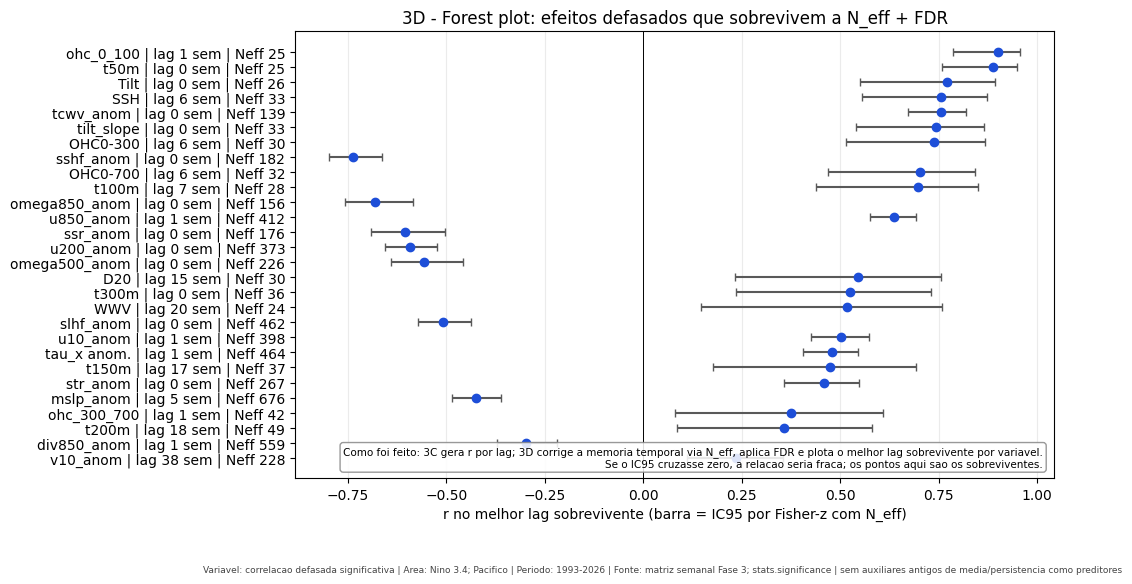

[tabela] data/processed/parquet/statistics/phase3D_forest_ic95_legenda.csv


PosixPath('/mnt/c/DEV/NINO26/data/processed/parquet/statistics/phase3D_forest_ic95_legenda.csv')

In [3]:
bb = best.reset_index().copy()
bb['label'] = [f"{u.var_label(v, short=True)} | lag {int(l)} sem | Neff {n:.0f}" for v, l, n in zip(bb['variavel'], bb['lag_semanas'], bb['n_eff'])]
bb = bb.sort_values('r', key=abs, ascending=True)
fig, ax = plt.subplots(figsize=(9.8, 5.8))
y = np.arange(len(bb))
err = np.vstack([bb['r'] - bb['ic95_low'], bb['ic95_high'] - bb['r']])
ax.errorbar(bb['r'], y, xerr=err, fmt='o', color='#1d4ed8', ecolor='0.35', capsize=3)
ax.axvline(0, color='k', lw=0.7)
ax.set_yticks(y)
ax.set_yticklabels(bb['label'])
ax.set_xlabel('r no melhor lag sobrevivente (barra = IC95 por Fisher-z com N_eff)')
ax.set_title('3D - Forest plot: efeitos defasados que sobrevivem a N_eff + FDR')
ax.grid(axis='x', alpha=.25)
u.add_note(ax, 'Como foi feito: 3C gera r por lag; 3D corrige a memoria temporal via N_eff, aplica FDR e plota o melhor lag sobrevivente por variavel.\nSe o IC95 cruzasse zero, a relacao seria fraca; os pontos aqui sao os sobreviventes.', loc='lower right')
u.stamp_caption(fig, variavel='correlacao defasada significativa', area='Nino 3.4; Pacifico', periodo='1993-2026', fonte='matriz semanal Fase 3; stats.significance', extra='sem auxiliares antigos de media/persistencia como preditores')
u.save_fig(fig, '3D1_forest_ic95.png')
plt.show()
qcol = 'q_fdr' if 'q_fdr' in bb.columns else ('q_valor' if 'q_valor' in bb.columns else None)
leg_cols = ['variavel','label','r','ic95_low','ic95_high','lag_semanas','n_eff'] + ([qcol] if qcol else [])
leg = bb[leg_cols].sort_values('r', key=abs, ascending=False)
u.save_table(leg, 'phase3D_forest_ic95_legenda.csv', index=False)


[figura] data/processed/figures/fase3/3D2_mapa_lon_lag_fdr.png


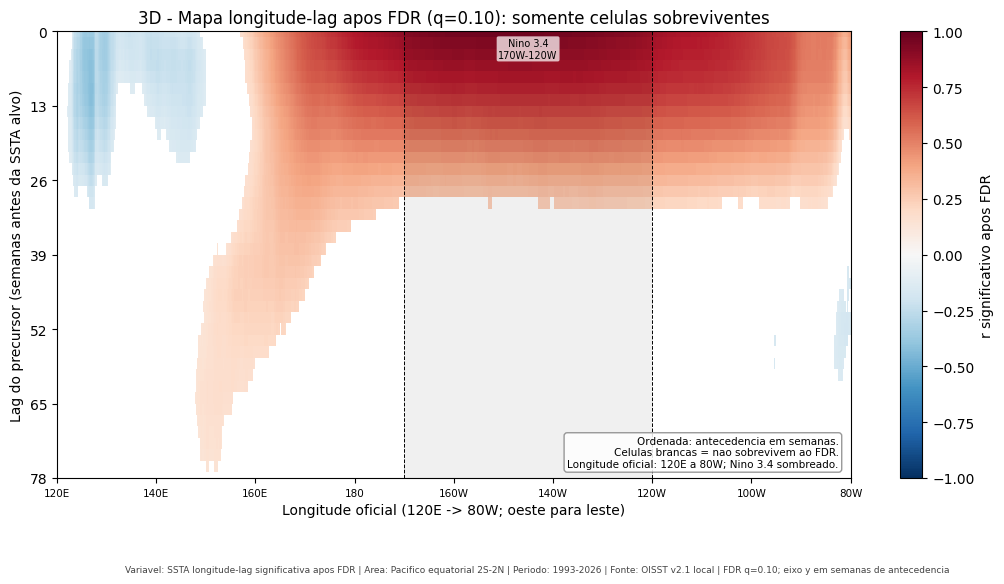

In [4]:
eq = u.load_eqband_weekly().loc['1993-01-01':]
eqa, ta = eq.align(tgt, join='inner', axis=0)
tv = ta.values
lags = list(range(0, 79, 2))
R = np.full((len(lags), eqa.shape[1]), np.nan)
Q = np.full_like(R, np.nan)
for i, l in enumerate(lags):
    X = eqa.values if l == 0 else eqa.iloc[:-l].values
    y = tv if l == 0 else tv[l:]
    for j in range(X.shape[1]):
        x = X[:, j]
        m = np.isfinite(x) & np.isfinite(y)
        if m.sum() > 60:
            r = float(np.corrcoef(x[m], y[m])[0, 1])
            neff = effective_sample_size(x[m], y[m])
            R[i, j] = r
            Q[i, j] = correlation_p_value(r, neff)
mask, _q = benjamini_hochberg_fdr(Q.ravel(), 0.10)
mask = mask.reshape(Q.shape)
lon = eqa.columns.values.astype(float)
fig, ax = plt.subplots(figsize=(12.8, 5.8))
M = np.where(mask, R, np.nan)
pc = ax.pcolormesh(lon, lags, M, cmap='RdBu_r', vmin=-1, vmax=1, shading='auto')
u.add_nino34_lon_band(ax)
u.format_lon_axis(ax)
u.format_lag_axis(ax, max_lag=max(lags))
ax.set_title('3D - Mapa longitude-lag apos FDR (q=0.10): somente celulas sobreviventes')
fig.colorbar(pc, ax=ax, label='r significativo apos FDR')
u.add_note(ax, 'Ordenada: antecedencia em semanas.\nCelulas brancas = nao sobrevivem ao FDR.\nLongitude oficial: 120E a 80W; Nino 3.4 sombreado.', loc='lower right')
u.stamp_caption(fig, variavel='SSTA longitude-lag significativa apos FDR', area='Pacifico equatorial 2S-2N', periodo='1993-2026', fonte='OISST v2.1 local', extra='FDR q=0.10; eixo y em semanas de antecedencia')
u.save_fig(fig, '3D2_mapa_lon_lag_fdr.png')
plt.show()


**Leitura do 3D.** A correcao por N_eff e severa: o N nominal ~1740 vira N_eff pequeno porque a memoria da serie consome graus de liberdade. Ainda assim sobrevivem, com sinal claro, variaveis fisicas do Pacifico: **tilt, SSH/OHC 0-300/0-700, D20, WWV e tau_x_anom**. O 3D define a evidencia inferencial; o 3E apenas quantifica sensibilidade por bootstrap em blocos e leave-one-event-out, sem breakpoint ou novo gate.


<!-- NINO26-REFERENCIAS v1 -->
## Referências Bibliográficas

1. Bretherton, C. S., et al. (1999). The Effective Number of Spatial Degrees of Freedom. *J. Climate*, 12, 1990-2009. https://doi.org/10.1175/1520-0442(1999)012<1990:TENOSD>2.0.CO;2
2. Benjamini, Y., & Hochberg, Y. (1995). Controlling the False Discovery Rate. *JRSS-B*, 57, 289-300. https://doi.org/10.1111/j.2517-6161.1995.tb02031.x
3. Wilks, D. S. (2016). 'The Stippling Shows Statistically Significant Grid Points'. *BAMS*, 97, 2263-2273. https://doi.org/10.1175/BAMS-D-15-00267.1

Relação completa em `Artigos_Referências/Referências_Bibliográficas.xls`.